In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Étape 1

In [2]:
df_transaction = pd.read_csv("data/transactions.csv")

In [3]:
df_transaction.head()

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom
3,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom
4,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France


In [8]:
# Nombre de transaction
nb_transaction = df_transaction["invoice_id"].count()
print(f"Le nombre de transaction est de : {nb_transaction}")

Le nombre de transaction est de : 1837137


In [12]:
# Convertir la colonne en format datetime
df_transaction["invoice_date"] = pd.to_datetime(df_transaction["invoice_date"])
# Vérifier la convertion
print(df_transaction.info())
# Crée une colonne année
df_transaction["annnée"] = df_transaction["invoice_date"].dt.year
# Vérifier
print(df_transaction.head())

<class 'pandas.DataFrame'>
RangeIndex: 1837137 entries, 0 to 1837136
Data columns (total 8 columns):
 #   Column        Dtype         
---  ------        -----         
 0   invoice_id    str           
 1   customer_id   float64       
 2   product_code  str           
 3   product_name  str           
 4   quantity      float64       
 5   unit_price    float64       
 6   invoice_date  datetime64[us]
 7   country       str           
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 112.1 MB
None
  invoice_id  customer_id product_code                      product_name  \
0     513574          NaN        22382        LUNCH BAG SPACEBOY DESIGN    
1     609421          NaN        21028          PURPLE GEMSTONE BRACELET   
2     515609          NaN       47591B          SCOTTIES CHILDRENS APRON   
3     501320      15123.0        22334  DINOSAUR PARTY BAG + STICKER SET   
4     521822      12714.0        21933   PINK VINTAGE PAISLEY PICNIC BAG   

   quantity  unit_price     

In [13]:
# Connaitre la période du dataset
date_min = min(df_transaction["annnée"])
date_max = max(df_transaction["annnée"])

print(f"la période du dataset part de {date_min} à {date_max}")

la période du dataset part de 2007 à 2011


In [14]:
def check_missing_data(df):
    """
    Calcule et affiche le pourcentage de valeurs manquantes par colonne.
    """
    # Calcul du pourcentage
    missing_pct = (df.isnull().sum() / len(df)) * 100
    
    # Création d'un petit tableau propre pour l'affichage
    summary = pd.DataFrame({
        'Colonnes': missing_pct.index,
        'Pourcentage (%)': missing_pct.values
    }).sort_values(by='Pourcentage (%)', ascending=False)
    
    return summary

In [15]:
# --- UTILISATION ---
res_cust = check_missing_data(df_transaction)
print("Analyse Touchpoints :")
print(res_cust)

Analyse Touchpoints :
       Colonnes  Pourcentage (%)
1   customer_id        22.766838
4      quantity         0.881099
3  product_name         0.410530
0    invoice_id         0.000000
2  product_code         0.000000
5    unit_price         0.000000
6  invoice_date         0.000000
7       country         0.000000
8        annnée         0.000000


Trois colonnes contiennent des valeurs manquantes, customers_id, quantity et prodcut_name. Avec respectivement 22,8%, 0,9 %, 0,4% de valerus null

# Étape 2

In [17]:
# Compter le nombre de doublons dans la colonne 'customer_id'
nb_doublons = df_transaction['invoice_id'].duplicated().sum()

# Calculer le pourcentage
pct_doublons = (nb_doublons / len(df_transaction)) * 100

print(f"Nombre de doublons : {nb_doublons}")
print(f"Pourcentage : {pct_doublons:.2f}%")

Nombre de doublons : 1583592
Pourcentage : 86.20%


In [19]:
# On compte les lignes où ce trio est identique
nb_doublons_trio = df_transaction.duplicated(subset=['invoice_id', 'customer_id', 'product_code']).sum()

print(f"Nombre de lignes en double (même facture, même client, même produit) : {nb_doublons_trio}")

Nombre de lignes en double (même facture, même client, même produit) : 46602


In [25]:
df_transaction[df_transaction["unit_price"]<0]

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country,annnée
81454,A563186,NaN,B,Adjust bad debt,1.0,-11062.06,2011-08-12 14:51:00,United Kingdom,2011
553841,A516228,NaN,B,Adjust bad debt,1.0,-44031.79,2010-07-19 11:24:00,United Kingdom,2010
1143162,A528059,NaN,B,Adjust bad debt,1.0,-38925.87,2010-10-20 12:04:00,United Kingdom,2010
1179724,A506401,NaN,B,Adjust bad debt,1.0,-53594.36,2010-04-29 13:36:00,United Kingdom,2010
1618681,A563187,NaN,B,Adjust bad debt,1.0,-11062.06,2011-08-12 14:52:00,United Kingdom,2011


In [29]:
df_transaction["line_total"] = df_transaction["quantity"] * df_transaction["unit_price"]

In [30]:
df_transaction.head()

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country,annnée,line_total
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom,2010,8.42
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom,2011,17.90
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom,2010,1.66
3,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom,2010,13.20
4,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France,2010,14.75


In [42]:
df_transaction_final = df_transaction[(df_transaction["unit_price"] > 0) & (df_transaction["quantity"] > 0)]

In [43]:
df_transaction_final.describe()

,customer_id,quantity,unit_price,invoice_date,annnée,line_total
count,1.383999e+06,1.790500e+06,1.790500e+06,1790500,1.790500e+06,1.790500e+06
mean,2.239822e+04,1.183912e+01,3.578638e+00,2010-11-29 20:01:46.985076,2.010359e+03,2.153703e+01
min,1.234600e+04,1.000000e+00,1.000000e-03,2007-07-06 12:20:00,2.007000e+03,1.000000e-03
25%,1.489700e+04,1.000000e+00,1.250000e+00,2010-06-06 12:20:00,2.010000e+03,3.950000e+00
50%,1.747200e+04,4.000000e+00,2.100000e+00,2010-12-01 14:32:00,2.010000e+03,1.020000e+01
75%,2.177000e+04,1.200000e+01,3.750000e+00,2011-06-23 12:20:00,2.011000e+03,1.785000e+01
max,6.344100e+04,8.099500e+04,2.511109e+04,2011-12-09 12:50:00,2.011000e+03,1.684696e+05
std,1.253269e+04,1.057022e+02,3.929917e+01,NaN,6.536259e-01,1.642263e+02


# Étape 3

### Distribution des achats :

In [44]:
df_transaction_final.head()

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country,annnée,line_total
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom,2010,8.42
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom,2011,17.90
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom,2010,1.66
3,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom,2010,13.20
4,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France,2010,14.75


Statistiques des paniers :
count    238279.000000
mean        161.835746
std         679.503890
min           0.190000
25%          20.550000
50%          51.000000
75%         136.500000
max      168469.600000
Name: line_total, dtype: float64


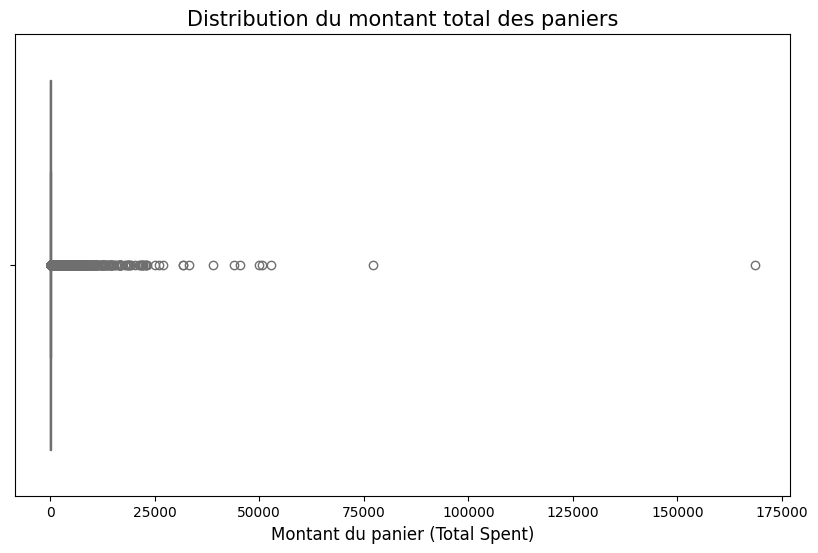

In [45]:
# 1. Calculer le montant total par panier (invoice_id)
# On groupe par invoice_id et on fait la somme des line_total
panier_totals = df_transaction_final.groupby('invoice_id')['line_total'].sum().reset_index()

# 2. Affichage des statistiques rapides (optionnel mais utile)
print("Statistiques des paniers :")
print(panier_totals['line_total'].describe())

# 3. Création du Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=panier_totals['line_total'], color="skyblue")

# Ajouter des titres et labels
plt.title('Distribution du montant total des paniers', fontsize=15)
plt.xlabel('Montant du panier (Total Spent)', fontsize=12)

# Sauvegarder l'image
plt.savefig('boxplot_paniers.png')

### Saisonnalité :